#  Behind the Drop: Revenue & Customer Analytics for a Corporate Travel Platform

**Objective:** Understand what is driving booking volume drops, identify cancellation patterns, and surface recommendations for leadership.

**Dataset:** 300,000 booking records across Air, Hotel, and Car from a corporate travel management platform — full year 2018.

| Section | Focus |
|---------|-------|
| 1. Data Overview | Dataset stats, product mix, booking types, data quality & cleaning |
| 2. Booking Trend Over Time | Monthly volume by product, demand patterns |
| 3. Booking Loss Analysis | Loss rates, monthly trends, July deep dive |
| 4. High-Loss Product Deep Dive: Car & Hotel | Hotel & Car-specific reserve/cancel patterns and lead time |
| 5. Revenue Analysis | Monthly revenue, gross vs losses, avg booking value |
| 6. User Behavior | Traveler frequency, revenue concentration, July segment drop |


## Setup


In [25]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110
con = duckdb.connect()
con.execute("""
    CREATE OR REPLACE VIEW bookings AS
    SELECT * FROM read_csv_auto('Egencia Analytics Case Study.csv', header=True)
""")
COLORS = {'Air': '#3498db', 'Hotel': '#2ecc71', 'Car': '#e74c3c'}
print('Setup complete. Raw bookings view ready.')

Setup complete. Raw bookings view ready.


## 1. Data Overview

High-level stats, product mix, booking type breakdown, data quality issues, and clean dataset creation.


In [26]:
stats = con.execute("""
    SELECT COUNT(*) AS total_records, COUNT(DISTINCT BOOKING_ID) AS unique_bookings,
           COUNT(DISTINCT TRAVELER_ID) AS unique_travelers,
           MIN(BOOKING_DATE) AS date_from, MAX(BOOKING_DATE) AS date_to,
           COUNT(DISTINCT PRODUCT_NAME) AS products, COUNT(DISTINCT BOOKING_TYPE_NAME) AS booking_types
    FROM bookings
""").df()
print('=== Raw Dataset Summary ===')
print(stats.T.to_string(header=False))

=== Raw Dataset Summary ===
total_records                  300000
unique_bookings                299977
unique_travelers                 6480
date_from         2018-01-01 00:00:00
date_to           2018-12-31 00:00:00
products                            3
booking_types                       7


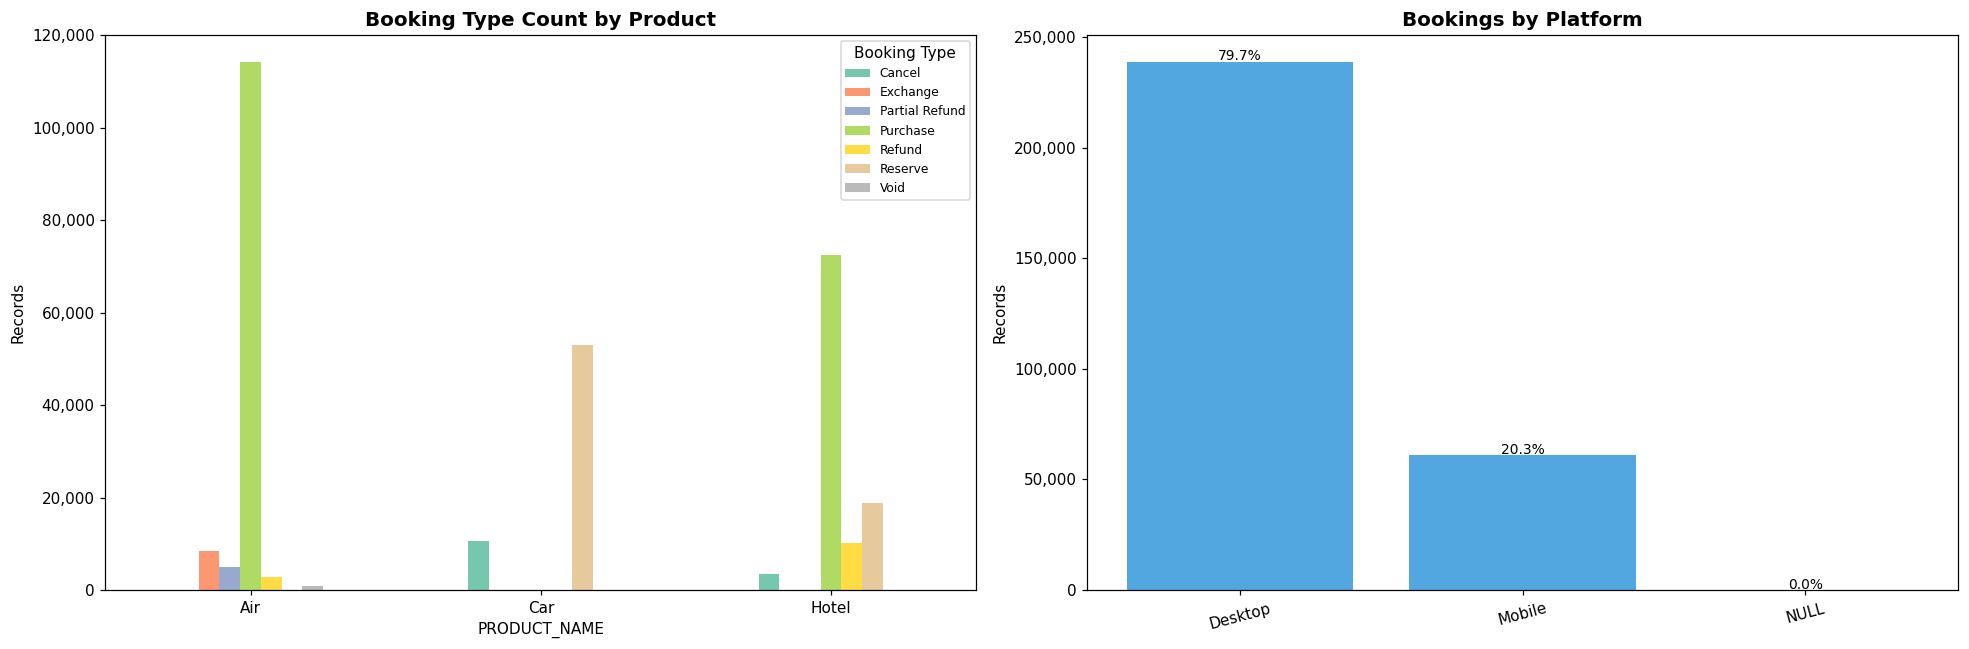


=== Booking Type by Product ===
PRODUCT_NAME BOOKING_TYPE_NAME      n  pct
         Air          Purchase 114286 86.9
         Air          Exchange   8528  6.5
         Air    Partial Refund   4962  3.8
         Air            Refund   2898  2.2
         Air              Void    893  0.7
         Car           Reserve  53077 83.4
         Car            Cancel  10560 16.6
       Hotel          Purchase  72393 69.1
       Hotel           Reserve  18798 17.9
       Hotel            Refund  10160  9.7
       Hotel            Cancel   3445  3.3


In [27]:
type_by_product = con.execute("""
    SELECT PRODUCT_NAME, BOOKING_TYPE_NAME, COUNT(*) AS n,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY PRODUCT_NAME),1) AS pct
    FROM bookings GROUP BY 1,2 ORDER BY 1,3 DESC
""").df()
platform = con.execute("""
    SELECT PLATFORM, COUNT(*) AS n, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct
    FROM bookings GROUP BY 1 ORDER BY 2 DESC
""").df()

# Graph 
# Graph Creation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pivot = type_by_product.pivot_table(index='PRODUCT_NAME', columns='BOOKING_TYPE_NAME', values='n', fill_value=0)
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', alpha=0.9)
axes[0].set_title('Booking Type Count by Product', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Records')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Booking Type', fontsize=8, bbox_to_anchor=(1,1))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].bar(platform['PLATFORM'], platform['n'], color='#3498db', alpha=0.85)
axes[1].set_title('Bookings by Platform', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Records')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i, (_, row) in enumerate(platform.iterrows()):
    axes[1].text(i, row['n']+500, f"{row['pct']}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('\n=== Booking Type by Product ===')
print(type_by_product.to_string(index=False))


### Data Quality & Cleaning

Before analysis, we run three standard checks on the raw data: revenue distribution, date logic, and duplicate records.

In [28]:
# --- 1. Revenue distribution: spot any extreme outliers ---
top_amounts = con.execute("""
    SELECT BOOKING_ID, ROUND(BOOKING_AMOUNT,2) AS amount, PRODUCT_NAME, BOOKING_TYPE_NAME
    FROM bookings ORDER BY ABS(BOOKING_AMOUNT) DESC LIMIT 10
""").df()
top_amounts['amount'] = top_amounts['amount'].map(lambda x: f'${x:,.0f}')
print('=== Top 10 Booking Amounts (by absolute value) ===')
print(top_amounts.to_string(index=False))

pct = con.execute("""
    SELECT ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY ABS(BOOKING_AMOUNT)),2) AS p50,
           ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY ABS(BOOKING_AMOUNT)),2) AS p95,
           ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY ABS(BOOKING_AMOUNT)),2) AS p99,
           ROUND(MAX(ABS(BOOKING_AMOUNT)),2) AS max_val
    FROM bookings WHERE BOOKING_AMOUNT != 0
""").df()
for col in ['p50','p95','p99','max_val']:
    pct[col] = pct[col].map(lambda x: f'${x:,.0f}')
print('\n=== Booking Amount Percentiles ===')
print(pct.to_string(index=False))

# --- 2. Date logic: flag impossible date combinations ---
date_issues = con.execute("""
    SELECT 'Travel end before travel start' AS check_name, COUNT(*) AS records
    FROM bookings
    WHERE TRAVEL_END < TRAVEL_START AND TRAVEL_END IS NOT NULL AND TRAVEL_START IS NOT NULL
    UNION ALL
    SELECT 'Travel start before booking date', COUNT(*)
    FROM bookings
    WHERE TRAVEL_START < BOOKING_DATE AND TRAVEL_START IS NOT NULL
""").df()
print('\n=== Date Logic Issues ===')
print(date_issues.to_string(index=False))

# --- 3. Duplicates: check for repeated BOOKING_IDs ---
dups = con.execute("""
    SELECT BOOKING_ID, COUNT(*) AS appearances
    FROM bookings GROUP BY BOOKING_ID HAVING COUNT(*) > 1
    ORDER BY appearances DESC LIMIT 5
""").df()
print(f'\n=== Duplicate BOOKING_IDs: {len(dups)} found ===')
print(dups.to_string(index=False) if len(dups) > 0 else 'None')

=== Top 10 Booking Amounts (by absolute value) ===
 BOOKING_ID        amount PRODUCT_NAME BOOKING_TYPE_NAME
 1973157021 $-100,021,332          Air            Refund
 2193047940   $24,420,422          Air          Purchase
 1565968544      $131,382          Air          Purchase
  802207388      $121,212          Air          Purchase
 1317472344      $118,567          Air          Purchase
 1355497482      $118,302          Air          Purchase
 2092650660      $118,006          Air          Purchase
 1437230858      $110,235          Air          Purchase
 1926300699     $-105,667          Air    Partial Refund
  216689106      $105,014          Air          Purchase

=== Booking Amount Percentiles ===
 p50    p95     p99      max_val
$766 $5,076 $15,817 $100,021,332

=== Date Logic Issues ===
                      check_name  records
  Travel end before travel start       20
Travel start before booking date     3690

=== Duplicate BOOKING_IDs: 5 found ===
 BOOKING_ID  appearances
  

**What we found:**
- **Revenue outlier**: BOOKING_ID `1973157021` = **-$100M** — a single Air Refund. The p99 is ~$15,800; this record is 6,000× that. Almost certainly a data entry error.
- **Date logic errors**: 20 records where travel end precedes travel start, or travel starts before the booking was made — physically impossible.
- **Duplicate BOOKING_IDs**: 23 booking IDs appear more than once. We keep the earliest record per ID using `ROW_NUMBER()`.

We exclude all three categories and create `bookings_clean` for all downstream analysis.

In [29]:
con.execute("""
    CREATE OR REPLACE VIEW bookings_clean AS
    SELECT * FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY BOOKING_ID ORDER BY BOOKING_DATE) AS rn
        FROM bookings
        WHERE BOOKING_ID != 1973157021
          AND NOT (TRAVEL_END < TRAVEL_START AND TRAVEL_END IS NOT NULL AND TRAVEL_START IS NOT NULL)
          AND NOT (TRAVEL_START < BOOKING_DATE AND TRAVEL_START IS NOT NULL)
    ) WHERE rn = 1
""")
raw   = con.execute("SELECT COUNT(*) AS n FROM bookings").df()['n'].values[0]
clean = con.execute("SELECT COUNT(*) AS n FROM bookings_clean").df()['n'].values[0]
print(f'Raw records:   {raw:,}')
print(f'Clean records: {clean:,}  ({raw-clean:,} removed, {(raw-clean)/raw*100:.2f}%)')
print('bookings_clean view created. All sections below use this cleaned dataset.')

Raw records:   300,000
Clean records: 296,273  (3,727 removed, 1.24%)
bookings_clean view created. All sections below use this cleaned dataset.


## 2. Booking Trend Over Time

Monthly purchase volume by product.
- Air & Hotel: **Purchase** | Car: **Reserve** (no Purchase type)


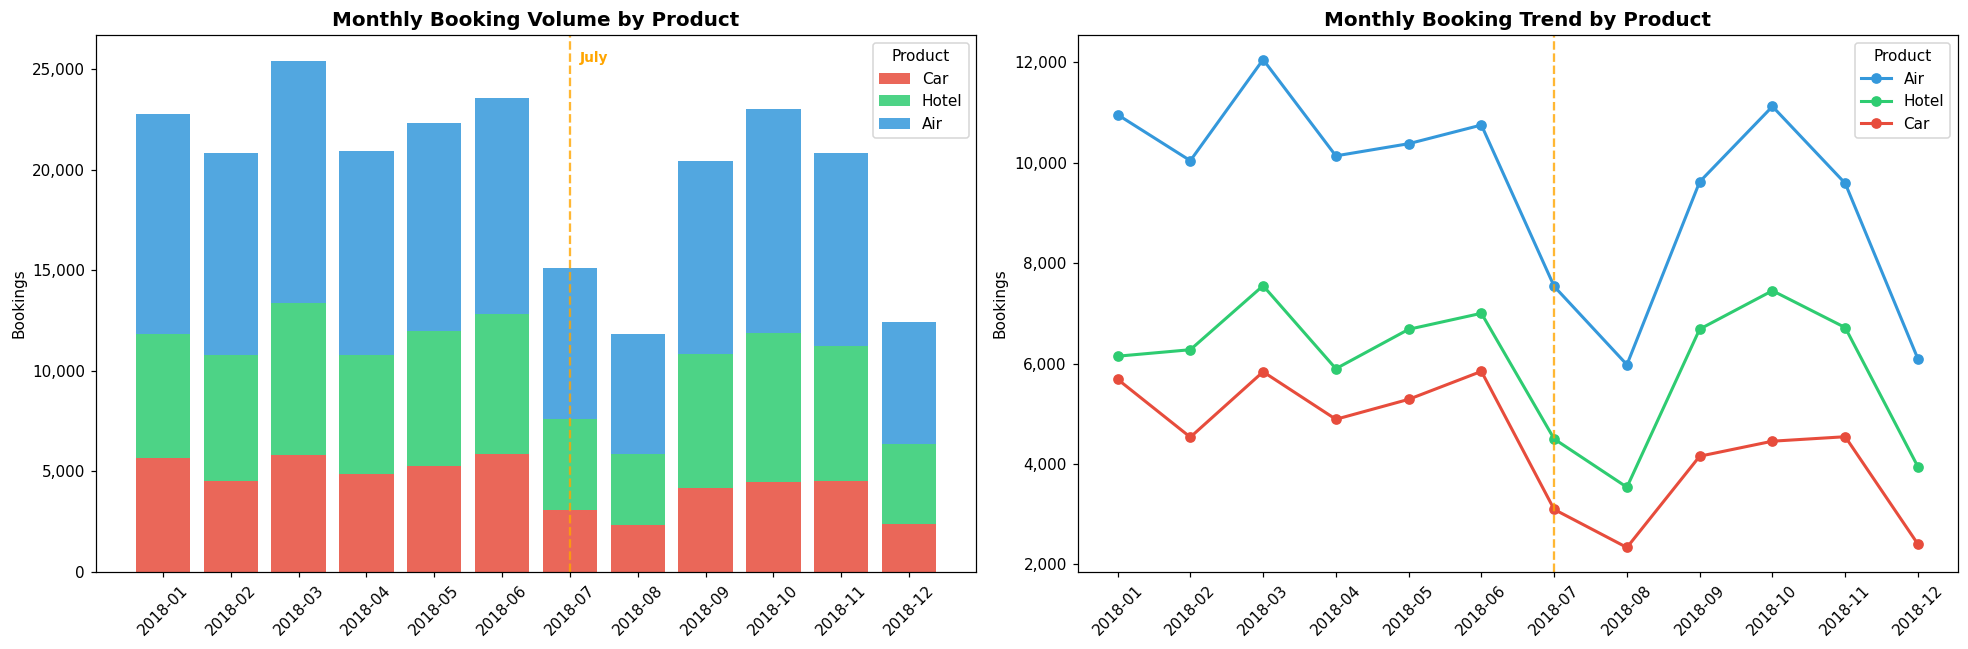

=== Monthly Volume & MoM Change ===
  month  total  mom_pct
2018-01  22787      NaN
2018-02  20847     -8.5
2018-03  25436     22.0
2018-04  20921    -17.8
2018-05  22344      6.8
2018-06  23592      5.6
2018-07  15131    -35.9
2018-08  11853    -21.7
2018-09  20458     72.6
2018-10  23022     12.5
2018-11  20846     -9.5
2018-12  12436    -40.3


In [30]:
monthly_vol = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month, PRODUCT_NAME, COUNT(*) AS bookings
    FROM bookings_clean
    WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
       OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
    GROUP BY 1,2 ORDER BY 1,2
""").df()
pivot = monthly_vol.pivot(index='month', columns='PRODUCT_NAME', values='bookings').fillna(0)
months = pivot.index.tolist()
july_idx = months.index('2018-07')
# Graph Creation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
bottom = [0]*len(months)
for product in ['Car','Hotel','Air']:
    vals = pivot[product].values
    axes[0].bar(months, vals, bottom=bottom, label=product, color=COLORS[product], alpha=0.85)
    bottom = [b+v for b,v in zip(bottom,vals)]
axes[0].set_title('Monthly Booking Volume by Product', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Bookings')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Product')
axes[0].axvline(x=july_idx, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].text(july_idx+0.15, axes[0].get_ylim()[1]*0.95, 'July', color='orange', fontsize=9, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for product in ['Air','Hotel','Car']:
    axes[1].plot(months, pivot[product], marker='o', label=product, color=COLORS[product], linewidth=2)
axes[1].set_title('Monthly Booking Trend by Product', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Bookings')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Product')
axes[1].axvline(x=july_idx, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()
mom = con.execute("""
    SELECT month, total, ROUND((total-LAG(total) OVER (ORDER BY month))*100.0/LAG(total) OVER (ORDER BY month),1) AS mom_pct
    FROM (
        SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month, COUNT(*) AS total
        FROM bookings_clean
        WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
           OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
        GROUP BY 1
    ) ORDER BY month
""").df()
print('=== Monthly Volume & MoM Change ===')
print(mom.to_string(index=False))


**Key Observations:**
- July collapsed to **15,131 bookings** — 32% below baseline avg 22,250
- August low volume driven by price spike, not cancellations
- December follows expected corporate holiday slowdown


## 3. High-Loss Month Booking Deep Dive: July
July is the single largest volume drop month at 32% below baseline. The drop could stem from a spike in booking losses or a collapse in new demand — two problems that require different interventions. Understanding *which* drove July shapes where to act.


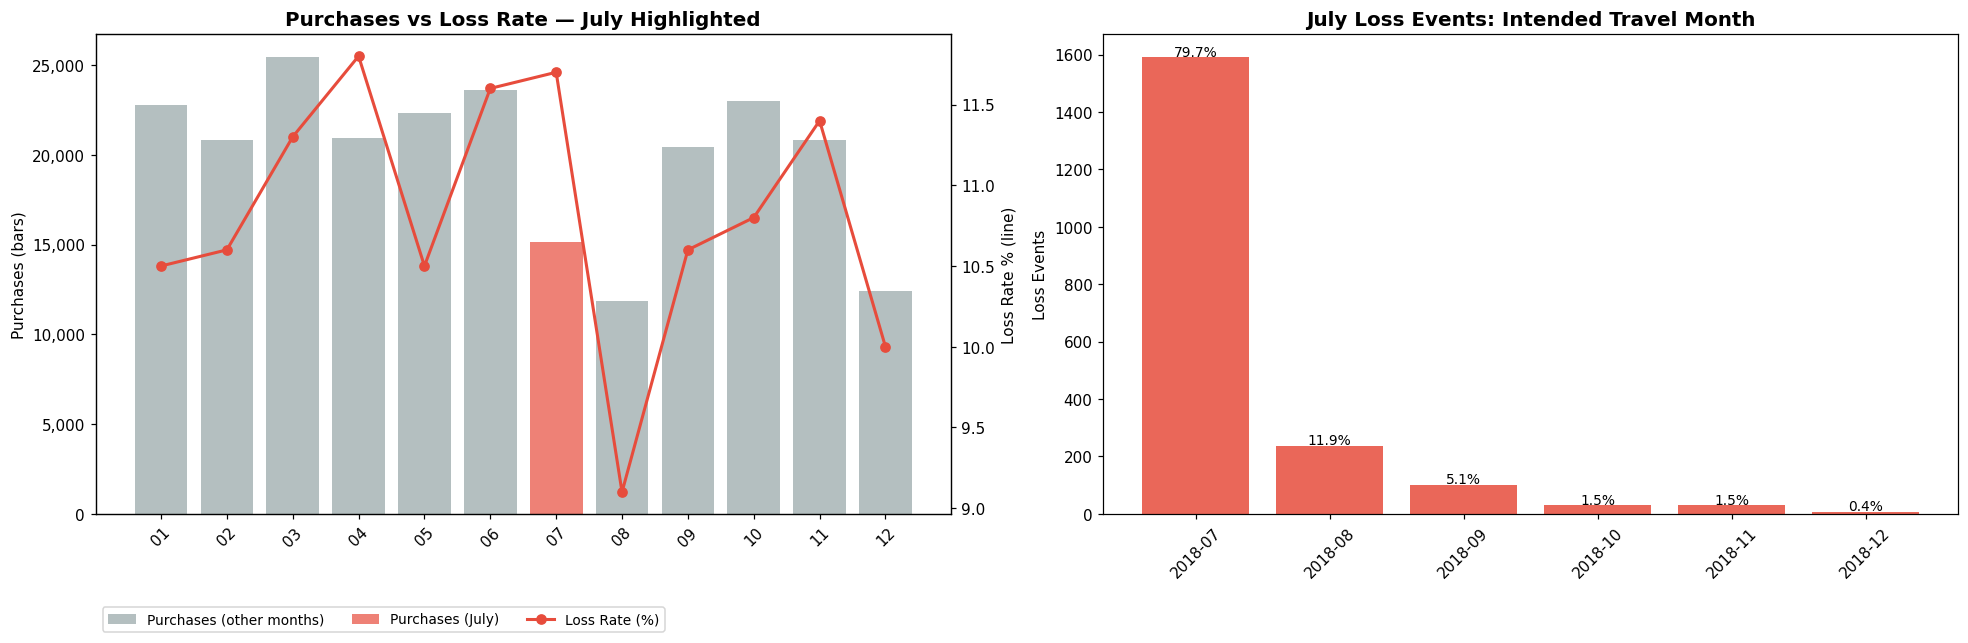

=== Monthly Purchases vs Loss Rate ===
month  purchases  loss_events  loss_rate_pct
   01    22787.0       2684.0           10.5
   02    20847.0       2469.0           10.6
   03    25436.0       3233.0           11.3
   04    20921.0       2806.0           11.8
   05    22344.0       2630.0           10.5
   06    23592.0       3089.0           11.6
   07    15131.0       1997.0           11.7
   08    11853.0       1185.0            9.1
   09    20458.0       2417.0           10.6
   10    23022.0       2796.0           10.8
   11    20846.0       2677.0           11.4
   12    12436.0       1380.0           10.0


In [32]:
july_vs_base = con.execute(f"""
    SELECT month, purchases, loss_events, ROUND(loss_events*100.0/NULLIF(purchases+loss_events,0),1) AS loss_rate_pct
    FROM (
        SELECT STRFTIME(BOOKING_DATE,'%m') AS month,
               SUM(CASE WHEN (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
                          OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve') THEN 1 ELSE 0 END) AS purchases,
               SUM(CASE WHEN {LOSS} THEN 1 ELSE 0 END) AS loss_events
        FROM bookings_clean GROUP BY 1
    ) ORDER BY month
""").df()
same_month = con.execute(f"""
    SELECT STRFTIME(TRAVEL_START,'%Y-%m') AS travel_month, COUNT(*) AS loss_events,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct
    FROM bookings_clean
    WHERE ({LOSS}) AND STRFTIME(BOOKING_DATE,'%Y-%m')='2018-07' AND TRAVEL_START IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").df()
# Graph Creation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax2 = axes[0].twinx()
bar_cols = ['#e74c3c' if m=='07' else '#95a5a6' for m in july_vs_base['month']]
axes[0].bar(july_vs_base['month'], july_vs_base['purchases'], color=bar_cols, alpha=0.7, label='Purchases')
line, = ax2.plot(july_vs_base['month'], july_vs_base['loss_rate_pct'], color='#e74c3c', marker='o', linewidth=2, label='Loss Rate (%)')
axes[0].set_title('Purchases vs Loss Rate — July Highlighted', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Purchases (bars)')
ax2.set_ylabel('Loss Rate % (line)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor='#95a5a6', alpha=0.7, label='Purchases (other months)'),
                  Patch(facecolor='#e74c3c', alpha=0.7, label='Purchases (July)'),
                  line]
axes[0].legend(handles=legend_handles, loc='upper left', fontsize=9, bbox_to_anchor=(0, -0.18), ncol=3)
axes[1].bar(same_month['travel_month'], same_month['loss_events'], color='#e74c3c', alpha=0.85)
axes[1].set_title('July Loss Events: Intended Travel Month', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loss Events')
axes[1].tick_params(axis='x', rotation=45)
for i, (_, row) in enumerate(same_month.iterrows()):
    axes[1].text(i, row['loss_events']+5, f"{row['pct']}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('=== Monthly Purchases vs Loss Rate ===')
print(july_vs_base.to_string(index=False))


**Key Insights:**
- **July loss rate (11.7%) is not exceptional** — demand collapsed 32%, that is the real issue
- **79.7% of July loss events** were for July travel — last-minute pullbacks
- **Hotel losses are 74.7% Refunds** at near-full purchase value — structural policy issue


## 4. High-Loss Product Deep Dive: Car & Hotel

Car (16.5%) and Hotel (13.0%) are the two highest-loss products. Each has a distinct workflow:

- **Car** — Reserve/Cancel only; no Purchase confirmation step
- **Hotel** — Losses split between Cancel (pre-stay) and Refund (post-booking adjustment)

Understanding *how* losses occur shapes the right intervention.

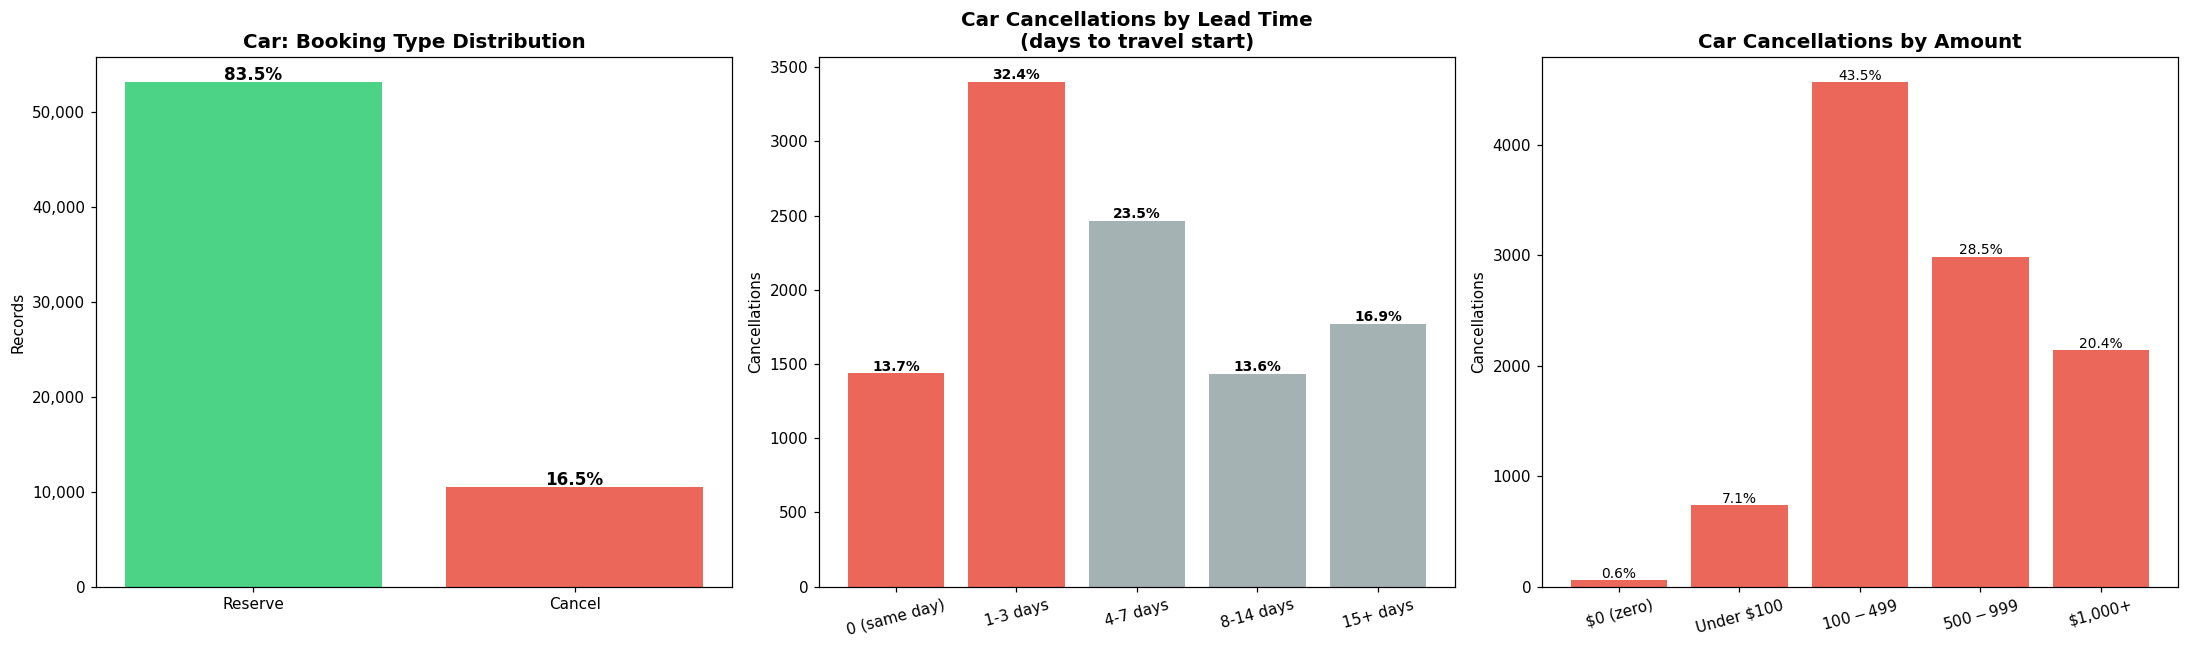

=== Car: Cancel Lead Time ===
 lead_bucket    n  pct
0 (same day) 1436 13.7
    1-3 days 3397 32.4
    4-7 days 2464 23.5
   8-14 days 1431 13.6
    15+ days 1771 16.9


In [33]:
car_types = con.execute("""
    SELECT BOOKING_TYPE_NAME, COUNT(*) AS n, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct
    FROM bookings_clean WHERE PRODUCT_NAME='Car' GROUP BY 1 ORDER BY 2 DESC
""").df()
car_lead = con.execute("""
    SELECT CASE
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) = 0              THEN '0 (same day)'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 1 AND 3  THEN '1-3 days'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 4 AND 7  THEN '4-7 days'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 8 AND 14 THEN '8-14 days'
               ELSE '15+ days'
           END AS lead_bucket, COUNT(*) AS n, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct
    FROM bookings_clean
    WHERE PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Cancel' AND TRAVEL_START IS NOT NULL
    GROUP BY 1 ORDER BY MIN(DATEDIFF('day',BOOKING_DATE,TRAVEL_START))
""").df()
car_amt = con.execute("""
    SELECT CASE
               WHEN ABS(BOOKING_AMOUNT)=0    THEN '$0 (zero)'
               WHEN ABS(BOOKING_AMOUNT)<100  THEN 'Under $100'
               WHEN ABS(BOOKING_AMOUNT)<500  THEN '$100-$499'
               WHEN ABS(BOOKING_AMOUNT)<1000 THEN '$500-$999'
               ELSE '$1,000+'
           END AS bucket, COUNT(*) AS n, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct
    FROM bookings_clean WHERE PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Cancel'
    GROUP BY 1 ORDER BY MIN(ABS(BOOKING_AMOUNT))
""").df()
# Graph Creation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].bar(car_types['BOOKING_TYPE_NAME'], car_types['n'], color=['#2ecc71','#e74c3c'], alpha=0.85)
axes[0].set_title('Car: Booking Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i, (_, row) in enumerate(car_types.iterrows()):
    axes[0].text(i, row['n']+200, f"{row['pct']}%", ha='center', fontsize=11, fontweight='bold')
bar_cols = ['#e74c3c' if '0' in b or '1-3' in b else '#95a5a6' for b in car_lead['lead_bucket']]
bars = axes[1].bar(car_lead['lead_bucket'], car_lead['n'], color=bar_cols, alpha=0.85)
axes[1].set_title('Car Cancellations by Lead Time\n(days to travel start)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cancellations')
axes[1].tick_params(axis='x', rotation=15)
for bar, (_, row) in zip(bars, car_lead.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, f"{row['pct']}%", ha='center', fontsize=9, fontweight='bold')
axes[2].bar(car_amt['bucket'], car_amt['n'], color='#e74c3c', alpha=0.85)
axes[2].set_title('Car Cancellations by Amount', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Cancellations')
axes[2].tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(car_amt.iterrows()):
    axes[2].text(i, row['n']+20, f"{row['pct']}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('=== Car: Cancel Lead Time ===')
print(car_lead.to_string(index=False))


**Car Key Insights:**
- Car operates on **Reserve/Cancel only** — no Purchase confirmation step
- **46% of cancels within 0–3 days** of travel start; same-day = 13.7% (1,436 records)
- Same-day spike likely reflects **system-expired holds**, not traveler-initiated cancels
- **99.4% carry real dollar amounts** — genuine financial exposure on every cancel

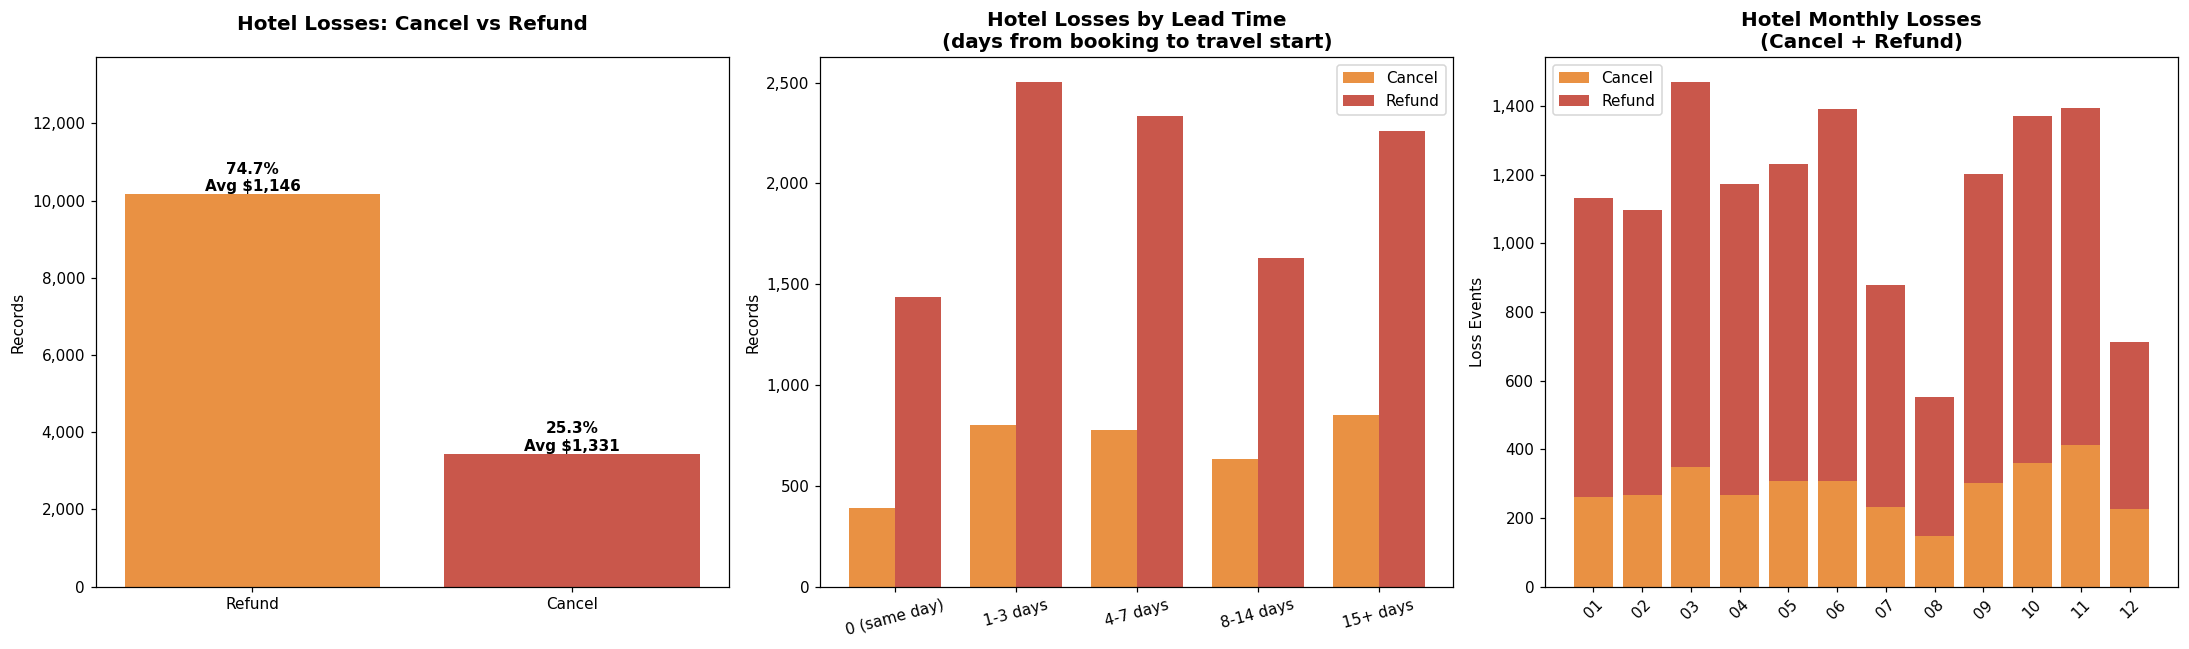

BOOKING_TYPE_NAME     n  pct  avg_amount
           Refund 10158 74.7     1145.78
           Cancel  3445 25.3     1331.27


In [34]:
hotel_split = con.execute("""
    SELECT BOOKING_TYPE_NAME, COUNT(*) AS n,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS pct,
           ROUND(AVG(ABS(BOOKING_AMOUNT)),2) AS avg_amount
    FROM bookings_clean
    WHERE PRODUCT_NAME='Hotel' AND BOOKING_TYPE_NAME IN ('Cancel','Refund')
    GROUP BY 1 ORDER BY 2 DESC
""").df()

hotel_lead = con.execute("""
    SELECT BOOKING_TYPE_NAME,
           CASE
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) = 0             THEN '0 (same day)'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 1 AND 3 THEN '1-3 days'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 4 AND 7 THEN '4-7 days'
               WHEN DATEDIFF('day',BOOKING_DATE,TRAVEL_START) BETWEEN 8 AND 14 THEN '8-14 days'
               ELSE '15+ days'
           END AS lead_bucket, COUNT(*) AS n
    FROM bookings_clean
    WHERE PRODUCT_NAME='Hotel' AND BOOKING_TYPE_NAME IN ('Cancel','Refund')
      AND TRAVEL_START IS NOT NULL
    GROUP BY 1,2 ORDER BY BOOKING_TYPE_NAME, MIN(DATEDIFF('day',BOOKING_DATE,TRAVEL_START))
""").df()

hotel_monthly = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month,
           SUM(CASE WHEN BOOKING_TYPE_NAME='Cancel' THEN 1 ELSE 0 END) AS cancels,
           SUM(CASE WHEN BOOKING_TYPE_NAME='Refund'  THEN 1 ELSE 0 END) AS refunds
    FROM bookings_clean
    WHERE PRODUCT_NAME='Hotel' AND BOOKING_TYPE_NAME IN ('Cancel','Refund')
    GROUP BY 1 ORDER BY 1
""").df()

# Graph Creation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Cancel vs Refund split
colors_split = ['#e67e22', '#c0392b']
bars = axes[0].bar(hotel_split['BOOKING_TYPE_NAME'], hotel_split['n'], color=colors_split, alpha=0.85)
axes[0].set_title('Hotel Losses: Cancel vs Refund', fontsize=13, fontweight='bold', pad=18)
axes[0].set_ylabel('Records')
axes[0].set_ylim(0, hotel_split['n'].max() * 1.35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, (_, row) in zip(bars, hotel_split.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f"{row['pct']}%\nAvg ${row['avg_amount']:,.0f}", ha='center', fontsize=10, fontweight='bold')

# Chart 2: Lead time by type (grouped bar)
buckets = ['0 (same day)','1-3 days','4-7 days','8-14 days','15+ days']
cancel_vals = hotel_lead[hotel_lead['BOOKING_TYPE_NAME']=='Cancel'].set_index('lead_bucket').reindex(buckets)['n'].fillna(0).values
refund_vals  = hotel_lead[hotel_lead['BOOKING_TYPE_NAME']=='Refund'].set_index('lead_bucket').reindex(buckets)['n'].fillna(0).values
x = range(len(buckets))
w = 0.38
axes[1].bar([i-w/2 for i in x], cancel_vals, width=w, label='Cancel', color='#e67e22', alpha=0.85)
axes[1].bar([i+w/2 for i in x], refund_vals,  width=w, label='Refund',  color='#c0392b', alpha=0.85)
axes[1].set_title('Hotel Losses by Lead Time\n(days from booking to travel start)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Records')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(buckets, rotation=15)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Chart 3: Monthly cancel+refund trend
months_short = [m[5:] for m in hotel_monthly['month']]
axes[2].bar(months_short, hotel_monthly['cancels'], label='Cancel', color='#e67e22', alpha=0.85)
axes[2].bar(months_short, hotel_monthly['refunds'],  bottom=hotel_monthly['cancels'],
            label='Refund', color='#c0392b', alpha=0.85)
axes[2].set_title('Hotel Monthly Losses\n(Cancel + Refund)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Loss Events')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.show()
print(hotel_split.to_string(index=False))

**Hotel Key Insights:**
- **74.7% of Hotel losses are Refunds**, not Cancels — suggesting post-booking adjustments or short-notice reversals rather than pre-trip opt-outs
- **Refunds avg $1,146 vs Cancels avg $1,331** — cancellations carry slightly higher per-event cost
- **Refunds cluster in 0–3 days** of travel start (38.6%) — indicative of last-minute reversals or policy-triggered refunds after check-in
- Monthly pattern mirrors overall volume: losses drop proportionally in Jul/Aug/Dec, not disproportionately elevated — Hotel loss rate is a structural, year-round issue
- **Opportunity**: distinguishing penalty-free cancels from refund-triggering events could reduce the 74.7% refund share through stricter booking policies

## 5. Revenue Analysis

Monthly gross revenue, losses, net revenue, and average booking value.


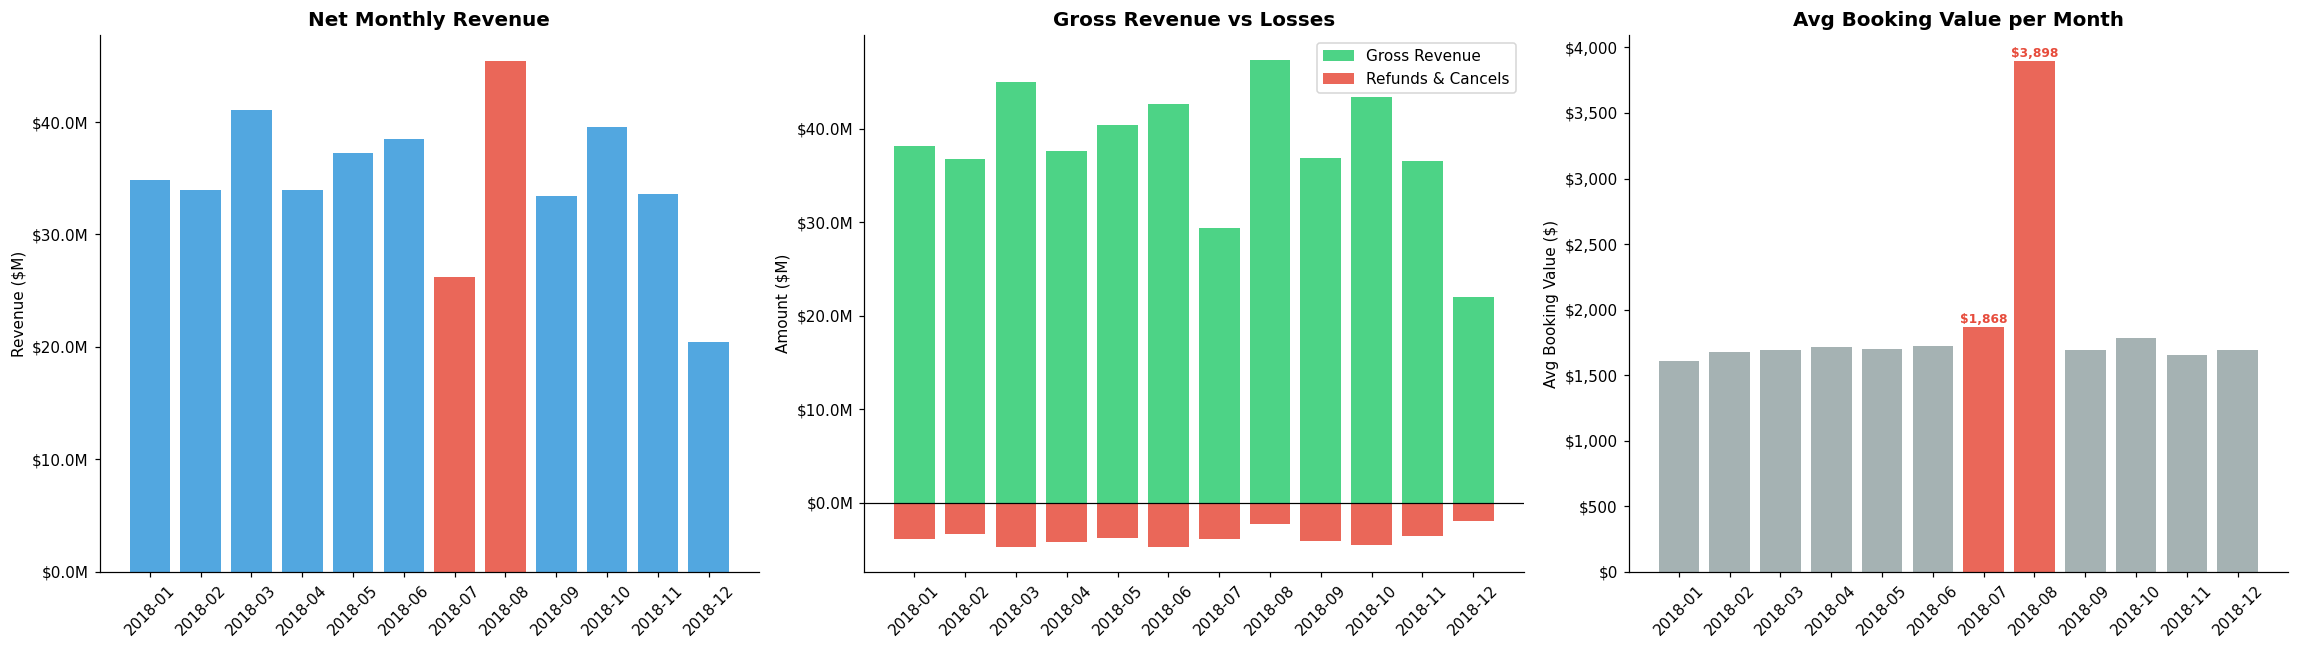

=== Monthly Revenue Summary ===
  month      gross    losses        net
2018-01 38150124.0 3809036.0 34811108.0
2018-02 36727244.0 3273688.0 33933640.0
2018-03 44955073.0 4764370.0 41042066.0
2018-04 37565617.0 4152596.0 33945313.0
2018-05 40432464.0 3755429.0 37264649.0
2018-06 42624979.0 4730847.0 38475857.0
2018-07 29427960.0 3853889.0 26176661.0
2018-08 47378653.0 2208819.0 45449653.0
2018-09 36828507.0 4083477.0 33397549.0
2018-10 43360916.0 4479059.0 39530099.0
2018-11 36499801.0 3558442.0 33558063.0
2018-12 22054263.0 1924274.0 20463761.0


In [132]:
monthly_rev = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month, PRODUCT_NAME,
           SUM(CASE WHEN BOOKING_TYPE_NAME IN ('Purchase','Reserve') THEN BOOKING_AMOUNT ELSE 0 END) AS gross,
           SUM(CASE WHEN BOOKING_TYPE_NAME IN ('Refund','Partial Refund','Cancel','Void') THEN ABS(BOOKING_AMOUNT) ELSE 0 END) AS losses,
           SUM(BOOKING_AMOUNT) AS net
    FROM bookings_clean GROUP BY 1,2 ORDER BY 1,2
""").df()
net_month = monthly_rev.groupby('month')[['gross','losses','net']].sum().reset_index()
avg_val = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month, COUNT(*) AS bookings,
           ROUND(AVG(BOOKING_AMOUNT),2) AS avg_value, ROUND(SUM(BOOKING_AMOUNT)/1e6,2) AS revenue_m
    FROM bookings_clean
    WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
       OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
    GROUP BY 1 ORDER BY 1
""").df()
# Graph Creation
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
bar_cols = ['#e74c3c' if m in ['2018-07','2018-08'] else '#3498db' for m in net_month['month']]
axes[0].bar(net_month['month'], net_month['net']/1e6, color=bar_cols, alpha=0.85)
axes[0].set_title('Net Monthly Revenue', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($M)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
x = range(len(net_month))
axes[1].bar(x, net_month['gross']/1e6, label='Gross Revenue', color='#2ecc71', alpha=0.85)
axes[1].bar(x, -net_month['losses']/1e6, label='Refunds & Cancels', color='#e74c3c', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Gross Revenue vs Losses', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($M)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(net_month['month'], rotation=45)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
bar_cols2 = ['#e74c3c' if m in ['2018-07','2018-08'] else '#95a5a6' for m in avg_val['month']]
axes[2].bar(avg_val['month'], avg_val['avg_value'], color=bar_cols2, alpha=0.85)
axes[2].set_title('Avg Booking Value per Month', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Booking Value ($)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, (_, row) in enumerate(avg_val.iterrows()):
    if row['month'] in ['2018-07','2018-08']:
        axes[2].text(i, row['avg_value']+30, f"${row['avg_value']:,.0f}", ha='center', fontsize=8, fontweight='bold', color='#e74c3c')
plt.tight_layout()
plt.show()
print('=== Monthly Revenue Summary ===')
print(net_month.round(0).to_string(index=False))


**Key Insights:**
- **July net revenue dropped sharply** — driven by 32% demand collapse, not a spike in losses
- **August revenue spiked** despite low volume — avg booking value $3,898 vs normal $1,600–$1,870
- **July avg value ($1,868)** slightly above baseline — essential high-value trips survived


## 6. Customer Behavior

Segment travelers by annual booking frequency:
- **Frequent (10+)** — core corporate travelers
- **Occasional (3–9)** — periodic business travelers
- **One-time (1–2)** — rare or single-trip travelers


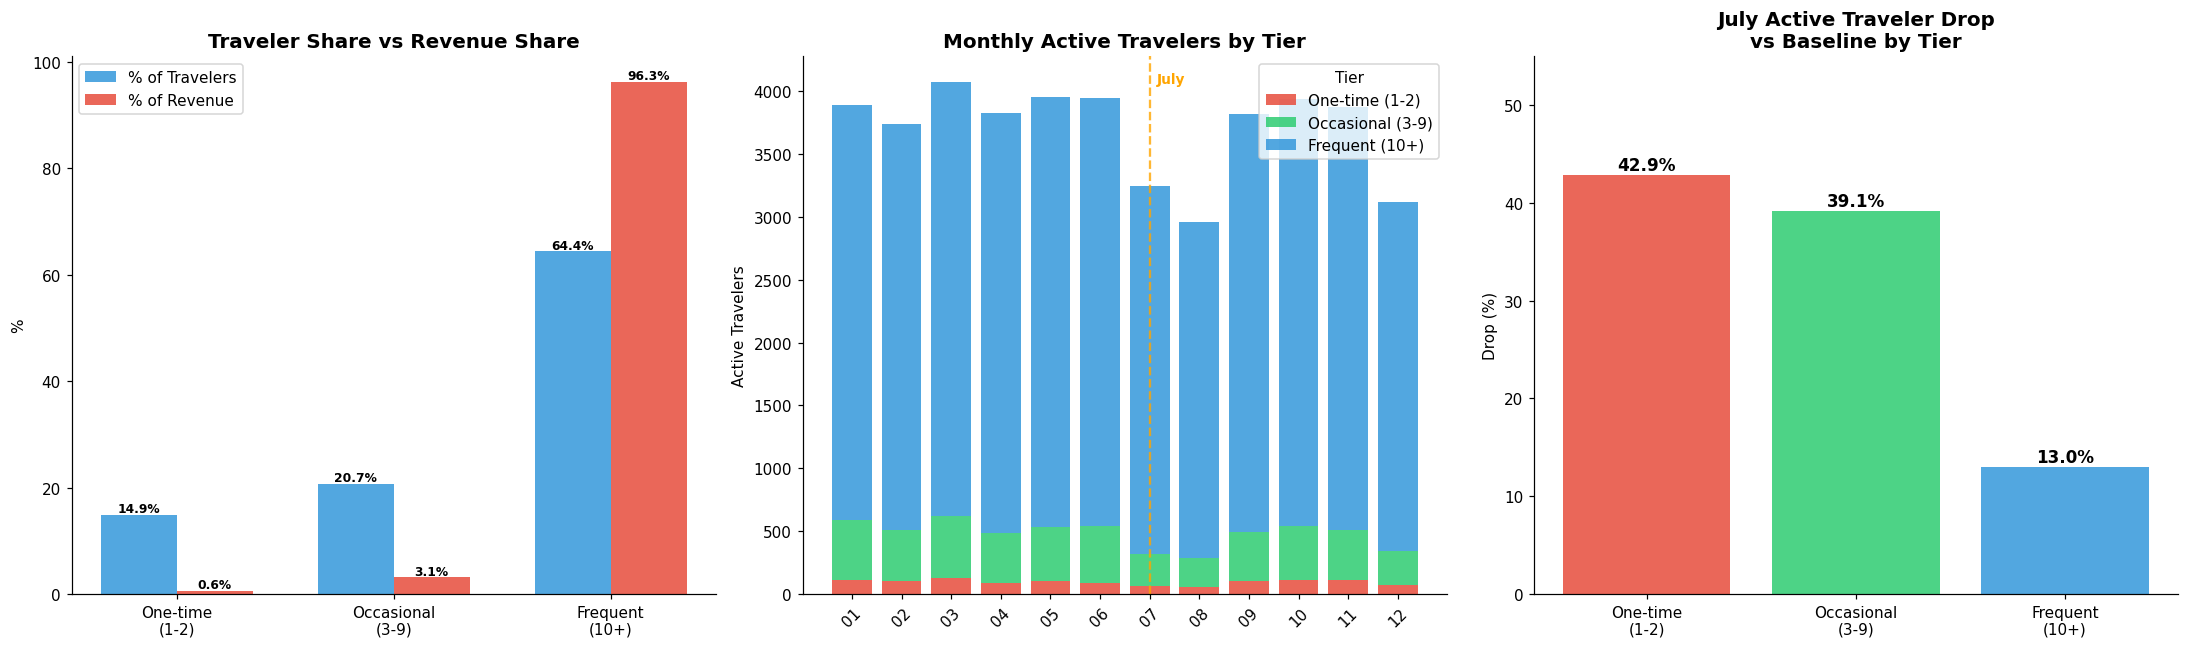

=== Traveler Tier Summary ===
       freq_tier  travelers  traveler_share  revenue_share  avg_trips  avg_spend
  Frequent (10+)       4171            64.4           96.3       55.4   100439.1
Occasional (3-9)       1339            20.7            3.1        5.6    10048.8
  One-time (1-2)        968            14.9            0.6        1.3     2562.2

=== July Drop by Tier ===
One-time (1-2)      : baseline 105  |  July 60  |  drop 42.9%
Occasional (3-9)    : baseline 429  |  July 261  |  drop 39.1%
Frequent (10+)      : baseline 3,362  |  July 2,927  |  drop 13.0%


In [133]:
traveler_annual = con.execute("""
    SELECT TRAVELER_ID,
           SUM(CASE WHEN (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
                      OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve') THEN 1 ELSE 0 END) AS purchases,
           SUM(CASE WHEN (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
                      OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve') THEN BOOKING_AMOUNT ELSE 0 END) AS total_spend
    FROM bookings_clean GROUP BY TRAVELER_ID
""").df()
traveler_annual['freq_tier'] = traveler_annual['purchases'].apply(
    lambda x: 'One-time (1-2)' if x<=2 else ('Occasional (3-9)' if x<=9 else 'Frequent (10+)')
)
tier_summary = traveler_annual.groupby('freq_tier').agg(
    travelers=('TRAVELER_ID','count'), total_spend=('total_spend','sum'),
    avg_spend=('total_spend','mean'), avg_trips=('purchases','mean')
).reset_index()
tier_summary['traveler_share'] = (tier_summary['travelers']/tier_summary['travelers'].sum()*100).round(1)
tier_summary['revenue_share']  = (tier_summary['total_spend']/tier_summary['total_spend'].sum()*100).round(1)
monthly_bookings = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%m') AS month, TRAVELER_ID FROM bookings_clean
    WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
       OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
""").df().merge(traveler_annual[['TRAVELER_ID','freq_tier']], on='TRAVELER_ID')
monthly_active = monthly_bookings.groupby(['month','freq_tier'])['TRAVELER_ID'].nunique().reset_index(name='active_travelers')
baseline_avg = monthly_active[~monthly_active['month'].isin(['07','08','12'])].groupby('freq_tier')['active_travelers'].mean()
july_active  = monthly_active[monthly_active['month']=='07'].set_index('freq_tier')['active_travelers']
tiers = ['One-time (1-2)','Occasional (3-9)','Frequent (10+)']
drops = [(baseline_avg[t]-july_active[t])/baseline_avg[t]*100 for t in tiers]
active_pivot = monthly_active.pivot(index='month', columns='freq_tier', values='active_travelers').fillna(0)
months = active_pivot.index.tolist()
july_idx = months.index('07')
tier_colors = {'Frequent (10+)':'#3498db','Occasional (3-9)':'#2ecc71','One-time (1-2)':'#e74c3c'}
tier_labels = ['One-time\n(1-2)','Occasional\n(3-9)','Frequent\n(10+)']
# Graph Creation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ts = tier_summary.set_index('freq_tier')
x = range(3); w = 0.35
t_shares = [ts.loc[t,'traveler_share'] for t in tiers]
r_shares = [ts.loc[t,'revenue_share']  for t in tiers]
b1 = axes[0].bar([i-w/2 for i in x], t_shares, w, label='% of Travelers', color='#3498db', alpha=0.85)
b2 = axes[0].bar([i+w/2 for i in x], r_shares, w, label='% of Revenue',   color='#e74c3c', alpha=0.85)
axes[0].set_title('Traveler Share vs Revenue Share', fontsize=13, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(tier_labels)
axes[0].legend()
for bar, val in zip(list(b1)+list(b2), t_shares+r_shares):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
bottom = [0]*len(months)
for tier in ['One-time (1-2)','Occasional (3-9)','Frequent (10+)']:
    vals = active_pivot[tier].values
    axes[1].bar(months, vals, bottom=bottom, label=tier, color=tier_colors[tier], alpha=0.85)
    bottom = [b+v for b,v in zip(bottom,vals)]
axes[1].set_title('Monthly Active Travelers by Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Active Travelers')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tier')
axes[1].axvline(x=july_idx, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].text(july_idx+0.15, axes[1].get_ylim()[1]*0.95, 'July', color='orange', fontsize=9, fontweight='bold')
bars = axes[2].bar(tier_labels, drops, color=[tier_colors[t] for t in tiers], alpha=0.85)
axes[2].set_title('July Active Traveler Drop\nvs Baseline by Tier', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Drop (%)')
axes[2].set_ylim(0, 55)
for bar, val in zip(bars, drops):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print('=== Traveler Tier Summary ===')
print(tier_summary[['freq_tier','travelers','traveler_share','revenue_share','avg_trips','avg_spend']].round(1).to_string(index=False))
print('\n=== July Drop by Tier ===')
for t, d in zip(tiers, drops):
    print(f"{t:20s}: baseline {baseline_avg[t]:,.0f}  |  July {int(july_active[t]):,}  |  drop {d:.1f}%")


**Key Insights:**
- **Frequent travelers (10+) drive 96.3% of revenue** — 64% of travelers, nearly all the money
- **July hit the periphery**: Occasional (−39.1%) and One-time (−42.9%) dropped ~3x harder than Frequent (−13.0%)
- Consistent with a **targeted corporate budget freeze** on non-essential trips
- Occasional travelers represent a **volume recovery opportunity**


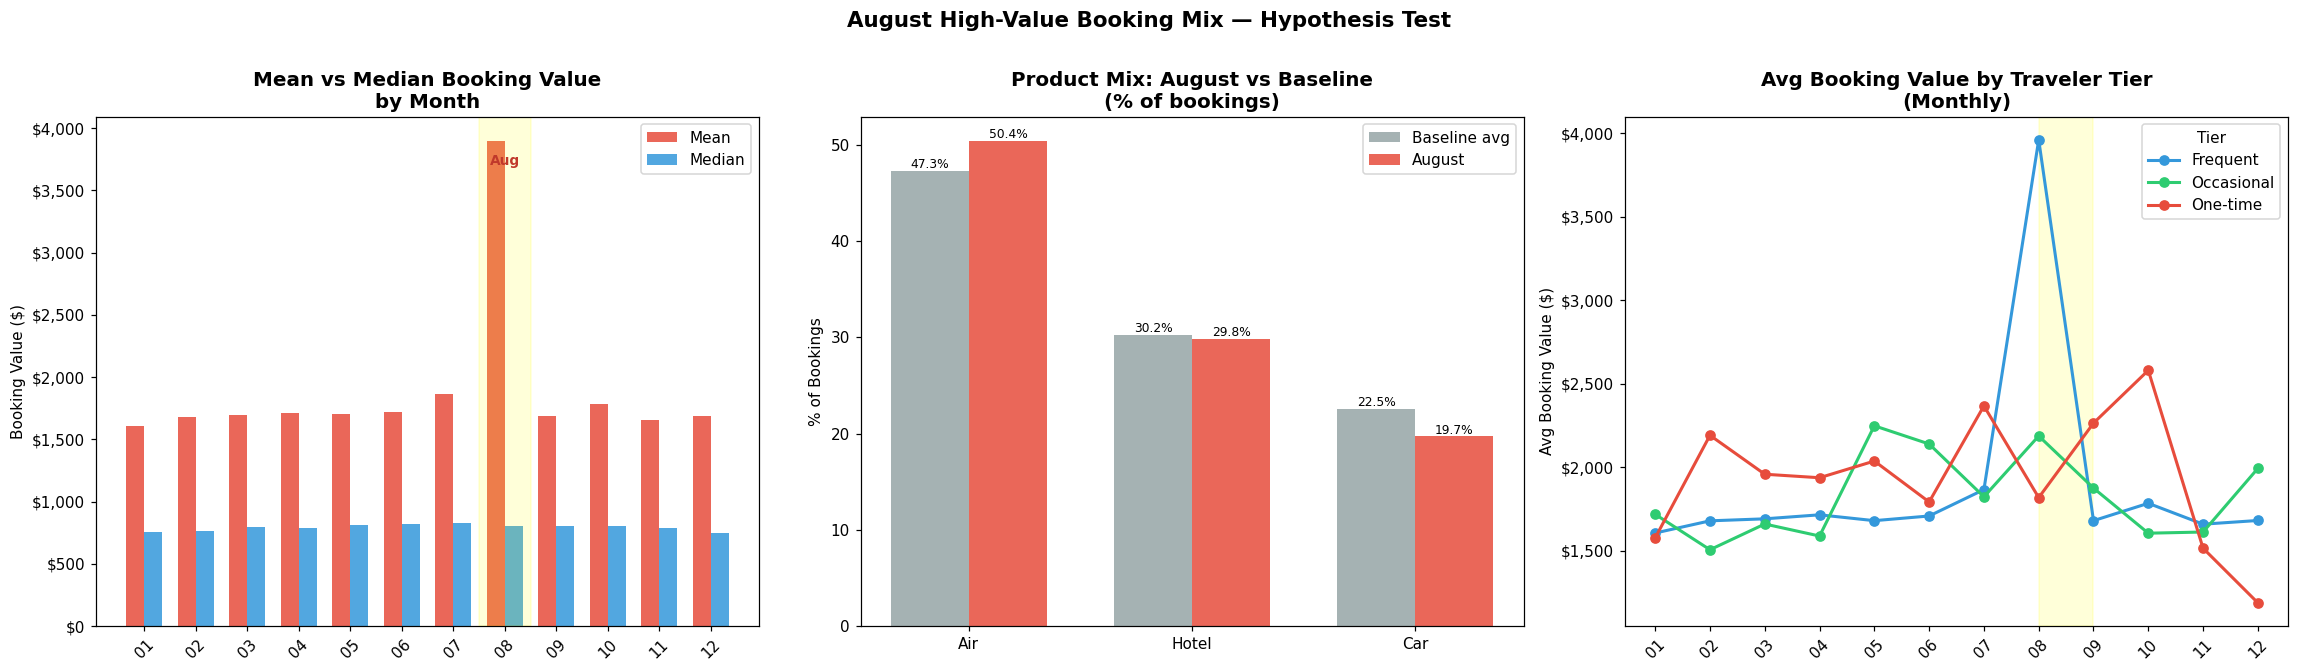

=== Mean vs Median ===
  month  mean_val  median_val    p90
2018-01    1610.0       757.0 3426.0
2018-02    1678.0       760.0 3497.0
2018-03    1692.0       797.0 3600.0
2018-04    1713.0       791.0 3558.0
2018-05    1700.0       809.0 3493.0
2018-06    1722.0       816.0 3602.0
2018-07    1868.0       825.0 3772.0
2018-08    3898.0       801.0 3613.0
2018-09    1691.0       801.0 3602.0
2018-10    1783.0       804.0 3640.0
2018-11    1658.0       786.0 3444.0
2018-12    1690.0       745.0 3471.0


In [35]:
# August high-value booking mix — 3 hypothesis test
mean_median = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month,
           ROUND(AVG(BOOKING_AMOUNT),0)                                                    AS mean_val,
           ROUND(MEDIAN(BOOKING_AMOUNT),0)                                                 AS median_val,
           ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY BOOKING_AMOUNT),0)           AS p90
    FROM bookings_clean
    WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
       OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
    GROUP BY 1 ORDER BY 1
""").df()

product_mix = con.execute("""
    SELECT STRFTIME(BOOKING_DATE,'%Y-%m') AS month, PRODUCT_NAME,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(PARTITION BY STRFTIME(BOOKING_DATE,'%Y-%m')),1) AS pct
    FROM bookings_clean
    WHERE (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
       OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve')
    GROUP BY 1,2 ORDER BY 1,2
""").df()

tier_monthly_avg = con.execute("""
    WITH tier AS (
        SELECT TRAVELER_ID,
               CASE WHEN SUM(CASE WHEN (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
                                    OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve') THEN 1 ELSE 0 END) <= 2
                    THEN 'One-time'
                    WHEN SUM(CASE WHEN (PRODUCT_NAME IN ('Air','Hotel') AND BOOKING_TYPE_NAME='Purchase')
                                    OR (PRODUCT_NAME='Car' AND BOOKING_TYPE_NAME='Reserve') THEN 1 ELSE 0 END) <= 9
                    THEN 'Occasional'
                    ELSE 'Frequent' END AS freq_tier
        FROM bookings_clean GROUP BY TRAVELER_ID
    )
    SELECT STRFTIME(b.BOOKING_DATE,'%Y-%m') AS month, t.freq_tier,
           ROUND(AVG(b.BOOKING_AMOUNT),0) AS avg_value
    FROM bookings_clean b JOIN tier t ON b.TRAVELER_ID = t.TRAVELER_ID
    WHERE (b.PRODUCT_NAME IN ('Air','Hotel') AND b.BOOKING_TYPE_NAME='Purchase')
       OR (b.PRODUCT_NAME='Car' AND b.BOOKING_TYPE_NAME='Reserve')
    GROUP BY 1,2 ORDER BY 1,2
""").df()

months_short = [m[5:] for m in mean_median['month']]
aug_idx = mean_median['month'].tolist().index('2018-08')

# Graph Creation
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('August High-Value Booking Mix — Hypothesis Test', fontsize=14, fontweight='bold', y=1.01)

# Chart 1: Mean vs Median by month
x = range(len(months_short))
w = 0.35
b1 = axes[0].bar([i-w/2 for i in x], mean_median['mean_val'],   width=w, label='Mean',   color='#e74c3c', alpha=0.85)
b2 = axes[0].bar([i+w/2 for i in x], mean_median['median_val'], width=w, label='Median', color='#3498db', alpha=0.85)
axes[0].set_title('Mean vs Median Booking Value\nby Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Booking Value ($)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(months_short, rotation=45)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].axvspan(aug_idx-0.5, aug_idx+0.5, color='yellow', alpha=0.15)
axes[0].text(aug_idx, mean_median['mean_val'].max()*0.95, 'Aug', ha='center', fontsize=9, color='#c0392b', fontweight='bold')

# Chart 2: Product mix Aug vs baseline
mix_pivot = product_mix.pivot(index='month', columns='PRODUCT_NAME', values='pct').fillna(0)
baseline_mix = mix_pivot[~mix_pivot.index.isin(['2018-07','2018-08','2018-12'])].mean()
aug_mix = mix_pivot.loc['2018-08']
products = ['Air','Hotel','Car']
x2 = range(len(products))
axes[1].bar([i-w/2 for i in x2], [baseline_mix[p] for p in products], width=w, label='Baseline avg', color='#95a5a6', alpha=0.85)
axes[1].bar([i+w/2 for i in x2], [aug_mix[p] for p in products],      width=w, label='August',       color='#e74c3c', alpha=0.85)
axes[1].set_title('Product Mix: August vs Baseline\n(% of bookings)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% of Bookings')
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(products)
axes[1].legend()
for i, p in enumerate(products):
    axes[1].text(i-w/2, baseline_mix[p]+0.3, f"{baseline_mix[p]:.1f}%", ha='center', fontsize=8)
    axes[1].text(i+w/2, aug_mix[p]+0.3,      f"{aug_mix[p]:.1f}%",      ha='center', fontsize=8)

# Chart 3: Avg booking value by tier — Jul / Aug / Sep
tiers = ['Frequent','Occasional','One-time']
tier_colors2 = {'Frequent':'#3498db','Occasional':'#2ecc71','One-time':'#e74c3c'}
for tier in tiers:
    d = tier_monthly_avg[tier_monthly_avg['freq_tier']==tier]
    axes[2].plot([m[5:] for m in d['month']], d['avg_value'],
                 marker='o', label=tier, color=tier_colors2[tier], linewidth=2)
axes[2].set_title('Avg Booking Value by Traveler Tier\n(Monthly)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Booking Value ($)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Tier')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[2].axvspan(7, 8, color='yellow', alpha=0.15)

plt.tight_layout()
plt.show()
print('=== Mean vs Median ===')
print(mean_median.to_string(index=False))

**August Booking Value — What the Data Shows:**
- Composition effect: Frequent traveler avg spiked to $ 3,961 in Aug vs $ 1,867 in Jul, but occasional/one-time were normal. Frequent travelers dominating a low-volume month amplifies the effect.
- A few large bookings skewing the mean: August booking median = 801, identical to every other month ($ 757–$ 816 range). The mean of $ 3,898 is entirely driven by outlier high-value bookings at the top end.

**Conclusion:** The August spike is a **statistical artifact, not a pricing or demand shift**. Median tells the true story — a typical August booking was no different from any other month.

---
## Key Findings & Recommendations

### Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | **July demand collapsed 32%** — 15,131 bookings vs baseline avg 22,250; loss rate was unremarkable | Demand |
| 2 | **79.7% of July cancellations were same-month trips** — last-minute corporate pullbacks | Behaviour |
| 3 | **Occasional & one-time travelers disappeared in July** (−39–43%); frequent travelers barely dipped (−13%) | Segmentation |
| 4 | **Car (16.5%) and Hotel (13.0%) carry elevated loss rates**; Air is lowest at 4.1% | Lost Revenue |
| 5 | **Car same-day cancellation spike** — 13.7% of cancels on travel date; cause (system-expired hold vs traveler-initiated) is unknown without reason codes | Operations |
| 6 | **Hotel losses are 74.7% Refunds** at near-full purchase value — stable ratio year-round | Process |
| 7 | **August mean booking value spiked to $3,898, but median was $801, identical to all other months.** Spike is driven by a handful of outlier bookings, not a genuine pricing shift | Pricing |
| 8 | **Frequent travelers generate 96.3% of revenue** — highly concentrated, high retention risk | Retention |

---

### Recommendations

#### Act — Finding is clear, recommendation is actionable

| # | Recommendation | Finding |
|---|---------------|---------|
| 1 | **Protect frequent travelers first** — 96.3% revenue concentration means any churn has outsized impact. Prioritize service quality and policy flexibility for this segment | F8 |
| 2 | **Re-engage occasional travelers before next summer** — they are the most volatile segment and the leading indicator of overall volume health | F3 |
| 3 | **Introduce tiered Car cancellation penalties by lead time** — 46% of cancels occur within 0–3 days and 99.4% carry real dollar amounts. A penalty structure (e.g. waived at 15+ days, partial at 4–14 days, full at 0–3 days) would reduce last-minute exposure without penalizing planned cancellations | F4, F5 |
| 4 | **Audit Hotel refund and cancellation policy** — 74.7% of Hotel losses are Refunds at avg $1,146, stable year-round. Review rate-type policies (flexible vs. non-refundable) to identify where the gap sits and design the right intervention | F6 |

#### Investigate — Signal is there, root cause unknown

| # | Question | What We Know | What We Need |
|---|----------|-------------|-------------|
| 1 | **Why did July demand collapse?** | Occasional travelers drove the drop; loss rate was normal — demand fell, not quality | Trip purpose data; corporate budget cycle; industry benchmarks to rule out platform-specific cause |
| 2 | **Are Car same-day cancels system or traveler-driven?** | 1,436 same-day cancels at avg $683; pattern is distinct from other lead time buckets | Cancellation reason codes from the booking system |
| 3 | **What triggers Hotel Refunds over Cancels?** | Ratio is consistent across all months — structural, not seasonal | Rate type at booking (flexible vs. non-refundable); refund reason codes. If refunds are coming from flexible rates, it's a policy design problem; if from non-refundable rates, it's an enforcement problem. Answer determines Act #4. |

#### Watch — Early indicator, not yet actionable

| # | Signal | Why It Matters |
|---|--------|---------------|
| 1 | **Occasional traveler booking velocity in May–Jun** — a leading indicator of whether July will repeat | F1, F3 |
| 2 | **August mean booking value in future low-volume months** — monitor whether outlier high-value bookings are a recurring pattern or a one-off artifact| F7 |